In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("sales.csv")
df.head()

,Order Date,Product,Category,Region,Sales,Quantity
0,2023-01-01,Headphones,Accessories,East,27144,7
1,2023-01-02,Monitor,Accessories,South,5000,9
2,2023-01-03,Tablet,Accessories,East,6052,8
3,2023-01-04,Monitor,Electronics,East,36506,6
4,2023-01-05,Monitor,Electronics,South,29074,8


In [7]:
df.isnull().sum() #shows the missing values

Order Date    0
Product       0
Category      0
Region        0
Sales         0
Quantity      0
dtype: int64

In [9]:
df = df.dropna() #removed whole rows with null values

In [10]:
df.head()

,Order Date,Product,Category,Region,Sales,Quantity
0,2023-01-01,Headphones,Accessories,East,27144,7
1,2023-01-02,Monitor,Accessories,South,5000,9
2,2023-01-03,Tablet,Accessories,East,6052,8
3,2023-01-04,Monitor,Electronics,East,36506,6
4,2023-01-05,Monitor,Electronics,South,29074,8


In [11]:
df['Sales'] = df['Sales'].fillna(df['Sales'].mean()) # filling mean data to missing data

In [12]:
df = df.drop_duplicates() #removing duplicate entries
print('Duplicates Removed')

Duplicates Removed


In [14]:
# Fixing date format
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Order Date  200 non-null    datetime64[ns]
 1   Product     200 non-null    object        
 2   Category    200 non-null    object        
 3   Region      200 non-null    object        
 4   Sales       200 non-null    int64         
 5   Quantity    200 non-null    int64         
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 9.5+ KB


In [16]:
# Standardising the text
df['Region'] = df['Region'].str.strip().str.title()
df['Product'] = df['Product'].str.strip().str.title()
df['Category'] = df['Category'].str.strip().str.title()


In [17]:
# Sanity Check
print(df['Sales'].min(), df['Sales'].max())
print(df['Quantity'].min(), df['Quantity'].max())

1412 49816
1 9


In [19]:
df['Revenue per Item'] = df['Sales'] / df['Quantity'] #Adding new column

In [20]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order Date        200 non-null    datetime64[ns]
 1   Product           200 non-null    object        
 2   Category          200 non-null    object        
 3   Region            200 non-null    object        
 4   Sales             200 non-null    int64         
 5   Quantity          200 non-null    int64         
 6   Revenue per Item  200 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(3)
memory usage: 11.1+ KB


In [22]:
total_revenue = df['Sales'].sum() #This gives overall business performance
print("Total Revenue", total_revenue)

Total Revenue 5253556


In [23]:
top_products = df.groupby('Product')['Sales'].sum().sort_values(ascending=False).head(5) # Grouping Data, Aggregaing sales and Sorting
print(top_products)

Product
Headphones    1275275
Laptop        1144168
Monitor        960424
Phone          946203
Tablet         927486
Name: Sales, dtype: int64


In [24]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False) # Which region is driving most revenue
print(region_sales)

Region
South    1582461
West     1488547
North    1217367
East      965181
Name: Sales, dtype: int64


In [25]:
# Monthly sales trend
df['Month'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Sales'].sum()
print(monthly_sales)

Month
2023-01    772563
2023-02    741385
2023-03    828988
2023-04    681502
2023-05    861508
2023-06    826811
2023-07    540799
Freq: M, Name: Sales, dtype: int64


In [26]:
# Category performance
category_sales = df.groupby('Category')['Sales'].sum()
print(category_sales)

Category
Accessories    2698440
Electronics    2555116
Name: Sales, dtype: int64


In [27]:
#Average Revenue per order
avg_order_value = df['Sales'].mean()
print(avg_order_value)

26267.78


In [29]:
# Best selling product (by quantity)
best_product_qty = df.groupby('Product')['Sales'].sum().sort_values(ascending = False)
print(best_product_qty)

Product
Headphones    1275275
Laptop        1144168
Monitor        960424
Phone          946203
Tablet         927486
Name: Sales, dtype: int64


In [31]:
# “Product Headphone generates the highest revenue”
# “Region South dominates overall sales”
# “Sales trend increases during [5th Month]”
# “Category Accessories contributes majority share”

In [32]:
# “I used grouping and aggregation to extract meaningful business insights from raw sales data.”

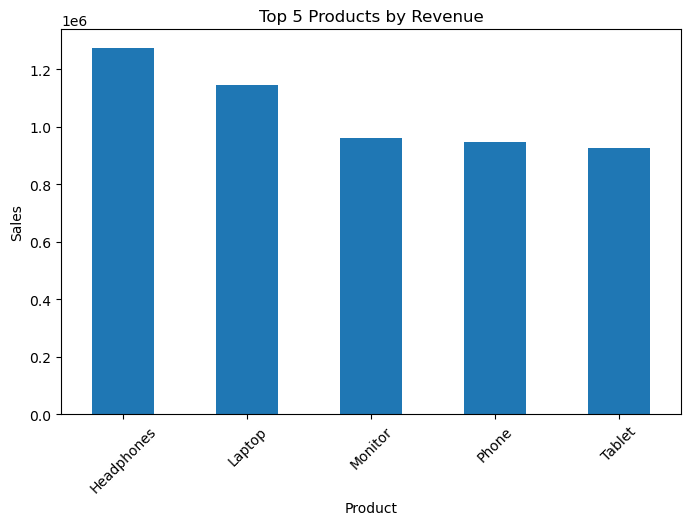

In [46]:
# Top Products - Bar Chart
plt.figure(figsize=(8,5))
top_products.plot(kind='bar')
plt.title("Top 5 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

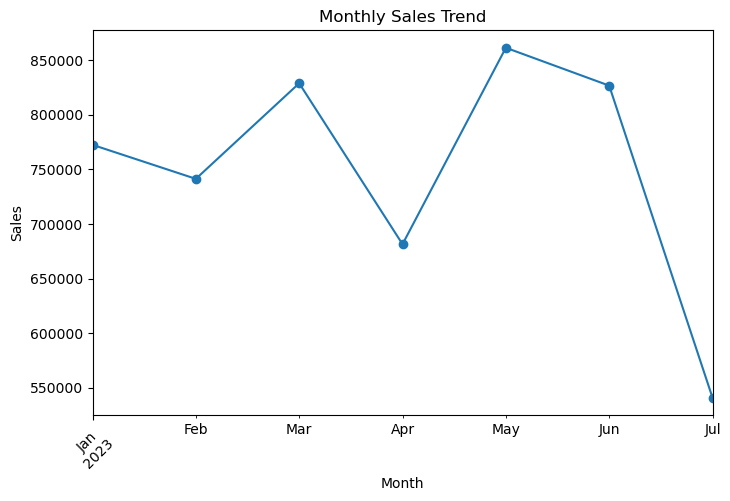

In [45]:
# Monthly sales trend - Line Chart
plt.figure(figsize=(8,5))
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

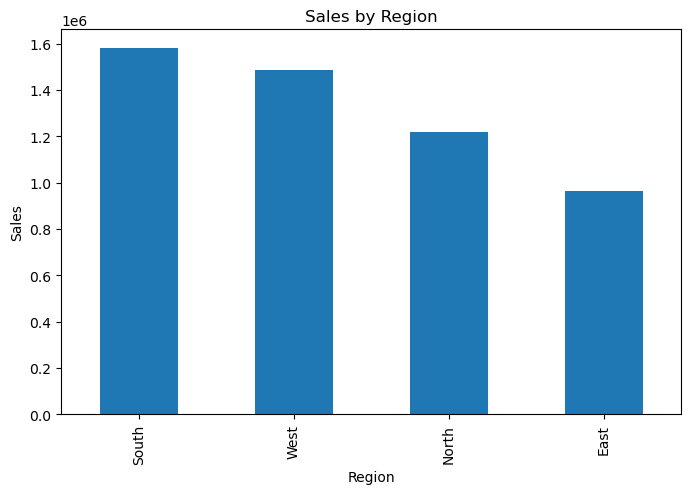

In [44]:
# Region wise sales - Bar Chart
plt.figure(figsize=(8,5))
region_sales.plot(kind='bar')
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

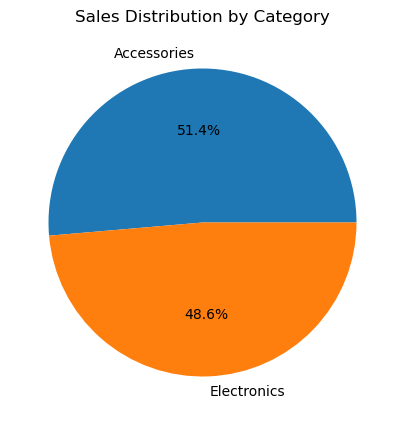

In [43]:
# Category distribution - Pie Chart
plt.figure(figsize=(8,5))
category_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales Distribution by Category")
plt.ylabel("") #removes extra label
plt.show()

In [ ]:
# Laptop Contributes Highest among all products
# Sales show steady growth over months
# West Region performs best, East needs improvement
# Elecronic Category dominates sales share